<a href="https://colab.research.google.com/github/hueglijoshua/CVI03.HS24-Computer-Vision/blob/main/04a_YOLO_object_detection_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First clone the repository locally:

git clone git@github.com:facebookresearch/segment-anything.git

cd segment-anything; pip install -e .

In [2]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx
!pip install segment-anything
!pip install torch torchvision
!pip install sam2


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Segmentation using YOLO

This notebooks aims to give a template to segment an individual dataset/pictures to further finetune a yolo model.

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [12]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import os
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
from google.colab import drive, files

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Set dataset path
dataset_path = "/content/drive/MyDrive/data_segmentation_yolo"

# Verify the dataset structure
os.listdir(dataset_path)

['test', 'val', 'train', 'data.yaml']

Several hyperparameters can be defined for our model. We set the warmup epochs to 3 and we set the values for data augmentation for hue, saturation and brightness. No rotation or shear should be introduced, but the vertical or horizontal flip probability are set to 0.5 and we also set the scale augmentation to 0.5. Below the several different options, including the selected ones, are shown.

In [20]:
# helper functions
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()
        

In [51]:
# FALSCH!
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_one(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1]))   # hier fehlt was
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8),cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours] # hier fehlt was
            mask_image = cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)
    ax.imshow(img)

In [21]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [26]:
# checkpoint-URL 
url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"

# Define the path where you want to save the checkpoint
save_path = "./segment-anything/sam2_/sam_vit_h_4b8939.pth"

# Send a GET request to download the file
response = requests.get(url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Save the content to a file
    with open(save_path, 'wb') as f:
        f.write(response.content)
    print(f"Checkpoint downloaded successfully and saved to {save_path}")
else:
    print("Failed to download checkpoint")


Checkpoint downloaded successfully and saved to ./segment-anything/sam2/sam_vit_h_4b8939.pth


In [6]:
# Load SAM model
sam = sam_model_registry["default"](checkpoint="./segment-anything/sam2_/sam_vit_h_4b8939.pth")
sam.to(device="cuda" if torch.cuda.is_available() else "cpu")

# Load image for segmentation
image = Image.open("./segment-anything/sam2_/test_xray.jpg")
image = np.array(image.convert("RGB"))

# Initialize the predictor
predictor = SamPredictor(sam)
predictor.set_image(image)

# Predict segmentation masks
masks = predictor.predict()

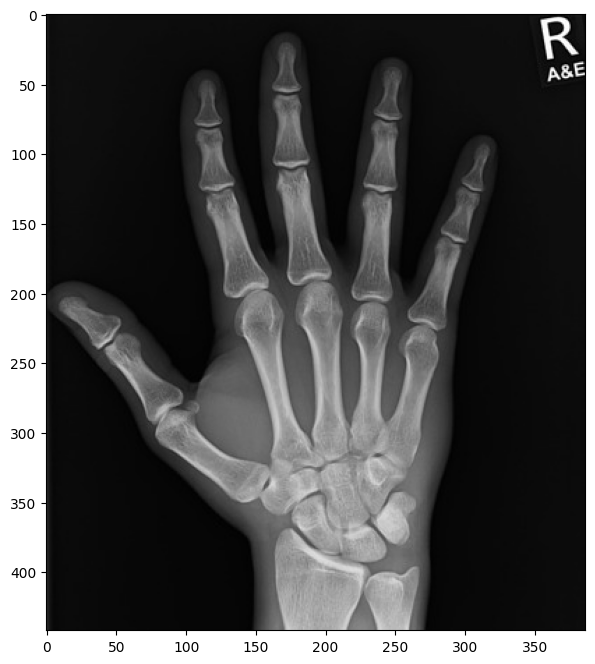

In [28]:
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('on')
plt.show()

# Automatically generating object masks with SAM

In [8]:
sam_checkpoint = "./segment-anything/sam2_/sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)


In [9]:
masks = mask_generator.generate(image)

In [34]:
print(len(masks))
print(masks[0].keys())

45
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


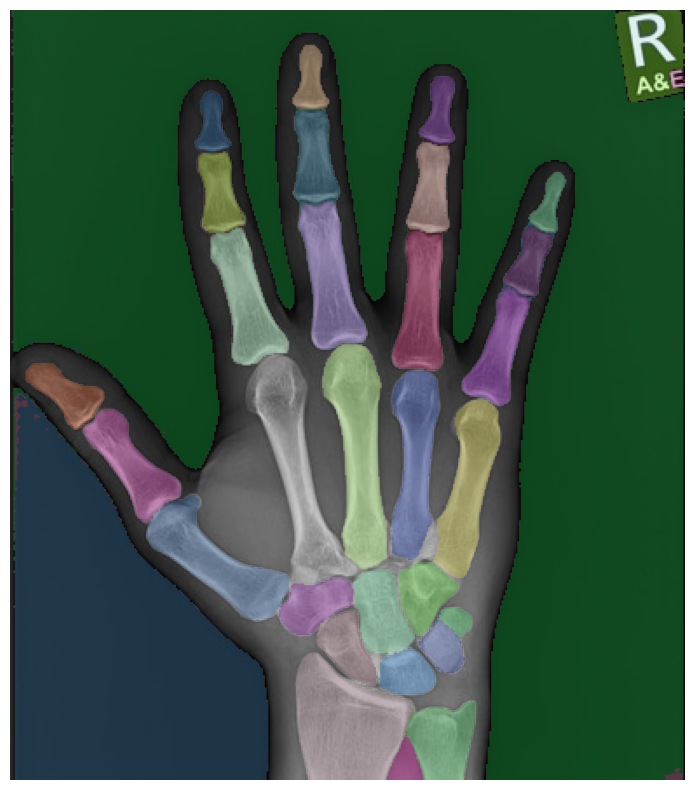

In [37]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 

In [38]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,                        # A higher value result in more detailed predictions
    pred_iou_thresh=0.86,                      # Predictions with an IoU lower than this threshold will be discarded
    stability_score_thresh=0.92,               # Masks with a stability score lower than this value are discarded
    crop_n_layers=1,                           # Defines # of layers in crop used for mask prediction. Helps generating more precise masks around object
    crop_n_points_downscale_factor=2,          # Downscales # of points for cropping. can speed up process while sacrificing precision
    min_mask_region_area=100,                  # minimum area for a mask region. Smaller regions will be discarded.
)

In [39]:
masks2 = mask_generator_2.generate(image)

In [40]:
len(masks2)

43

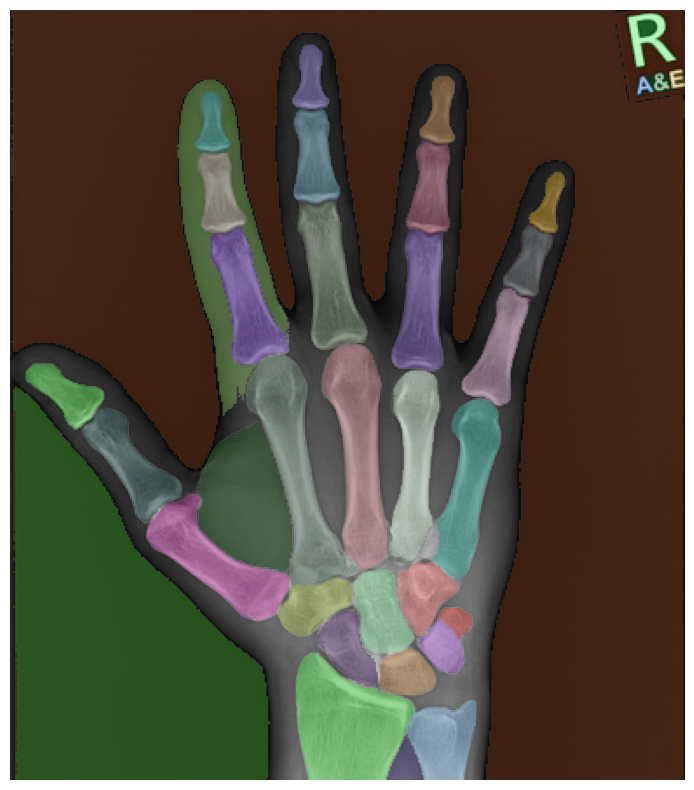

In [41]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show() 

# Selecting objects with SAM2

git clone https://github.com/facebookresearch/sam2.git && cd sam2

pip install -e .

In [6]:
%cd ./sam2

C:\Users\joshu\Documents\computervision\CVI03.HS24-Computer-Vision\sam2


C:\Users\joshu\Documents\computervision\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [7]:
import os
import subprocess
import requests

# Step 1: Define the download URL and target file path
url = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt"
checkpoints_dir = "./checkpoints"
file_name = "sam2.1_hiera_large.pt"
file_path = os.path.join(checkpoints_dir, file_name)

# Step 2: Create the checkpoints directory if it doesn't exist
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)

# Step 3: Download the file
response = requests.get(url)

# Step 4: Save the content to the file
if response.status_code == 200:
    with open(file_path, "wb") as f:
        f.write(response.content)
    print(f"File downloaded and saved to {file_path}")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved to ./checkpoints\sam2.1_hiera_large.pt


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [13]:
sam2_checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
device = "cpu"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device = device)

predictor = SAM2ImagePredictor(sam2_model)

Selected folder: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation
Opening first image: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\test_xray.jpg


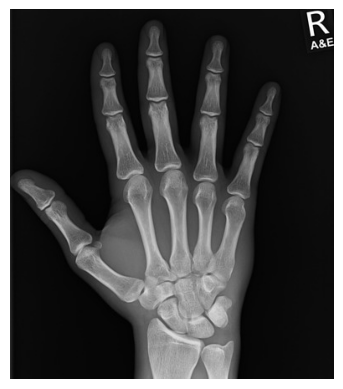

In [30]:
import os
import numpy as np
from tkinter import Tk, filedialog

# Function to select a folder
def select_folder():
    root = Tk()
    root.withdraw()  # Hide the root window
    folder_selected = filedialog.askdirectory(title="Select Image Folder")
    return folder_selected

# User selects the folder
image_folder = select_folder()
print(f"Selected folder: {image_folder}")

# Get the first image in the folder
if image_folder:
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        first_image_path = os.path.join(image_folder, image_files[0])
        print(f"Opening first image: {first_image_path}")
        
        # Load the image
        image = Image.open(first_image_path)
        image = np.array(image.convert("RGB"))
        
        # Display the image
        plt.imshow(image)
        plt.axis("off")
        plt.show()
    else:
        print("No images found in the selected folder.")
else:
    print("No folder selected.")


In [16]:
## Load image for segmentation
#image = Image.open("../segment-anything/sam2_/test_xray.jpg")
#image = np.array(image.convert("RGB"))

In [31]:
predictor.set_image(image)

In [71]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import simpledialog
from PIL import Image

# Initialize variables
input_point = None
input_label = None

def select_point(event, x, y, flags, param):
    """Handles mouse click event to capture (x, y) coordinates and request a label."""
    global input_point, input_label

    if event == cv2.EVENT_LBUTTONDOWN:
        input_point = np.array([[x, y]])  # Store selected point

        # Ask user for label (Foreground: 1, Background: 0)
        root = tk.Tk()
        root.withdraw()  # Hide the main Tkinter window
        label = simpledialog.askinteger("Input", "Enter label (1 = Foreground, 0 = Background):", minvalue=0, maxvalue=1)
        
        if label is not None:
            input_label = np.array([label])
            print(f"Selected point: {input_point}, Label: {input_label}")
            cv2.destroyAllWindows()  # Close the image window

# Convert image from PIL to OpenCV format
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Create a window and set mouse callback function
cv2.namedWindow("Select Point")
cv2.setMouseCallback("Select Point", select_point)

# Display image in pop-up window
while True:
    cv2.imshow("Select Point", image_cv)
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'Esc' to exit
        break

cv2.destroyAllWindows()


Selected point: [[248 420]], Label: [1]


In [18]:
#input_point = np.array([[60, 250]])
#input_label = np.array([1])                   # 1: foreground point or 0: background point

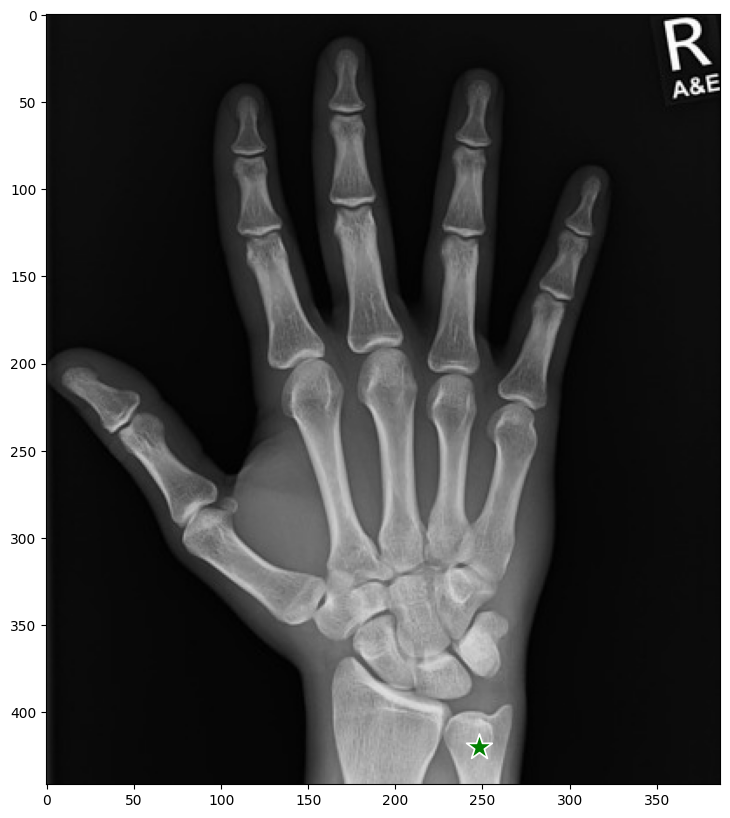

In [72]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show() 

In [66]:
print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


In [73]:
masks, scores, logits = predictor.predict(
    point_coords = input_point,
    point_labels = input_label,
    multimask_output = True,
)
#sorted_ind = np.argsort(scores)[::-1]
#masks = masks[sorted_ind]
#scores = scores[sorted_ind]
#logits = logits[sorted_ind]

In [54]:
masks.shape # (number_of_masks) x H x W

(3, 442, 387)

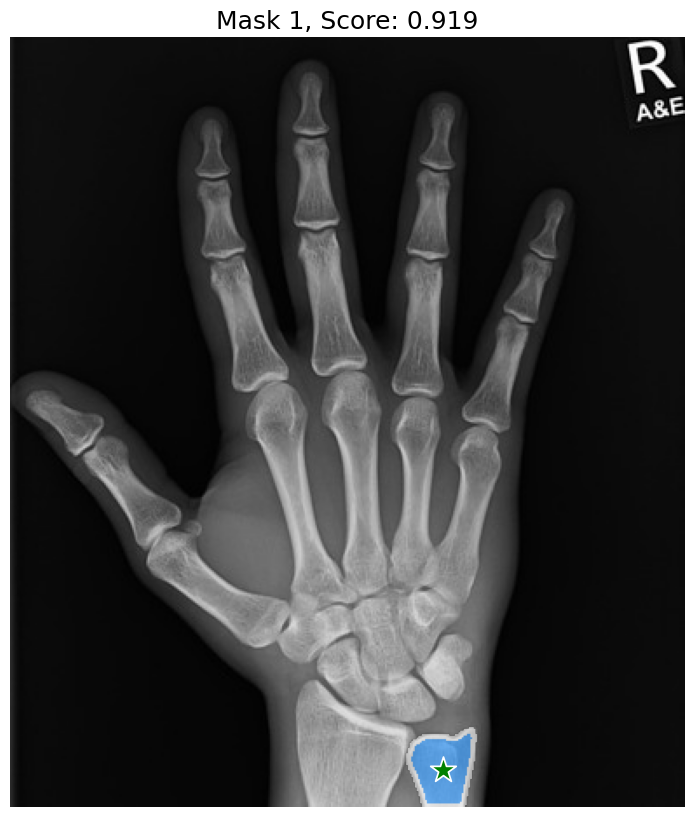

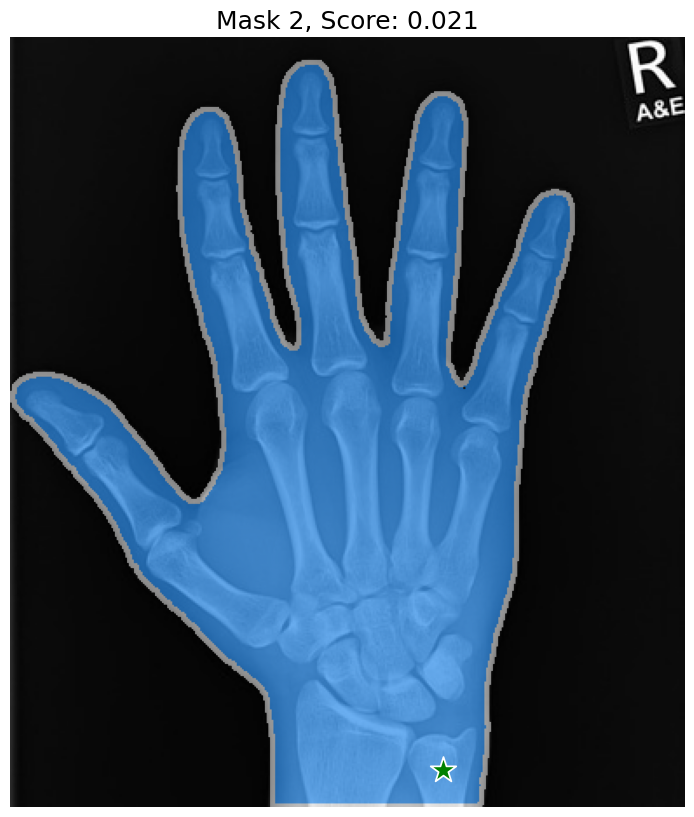

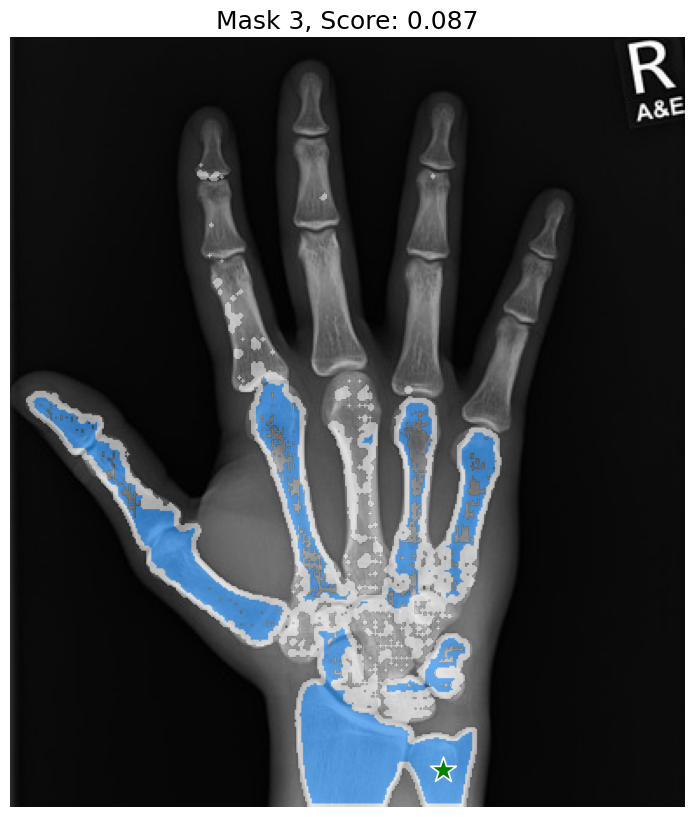

In [74]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

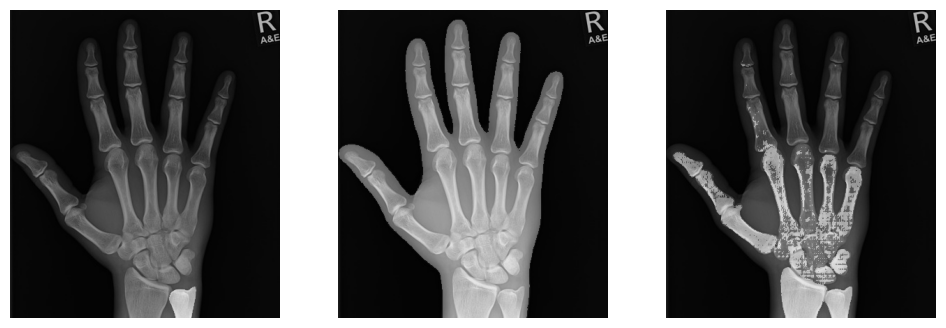

User selected Mask 1


In [81]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import simpledialog
import matplotlib.pyplot as plt

# Function to display masks side-by-side without individual labels
def choose_mask(image, masks, scores):
    """Displays the three masks side by side and allows the user to select one."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    for i in range(3):
        mask_overlay = (masks[i] * 255).astype(np.uint8)
        image_with_mask = cv2.addWeighted(image, 0.7, cv2.cvtColor(mask_overlay, cv2.COLOR_GRAY2BGR), 0.3, 0)

        axes[i].imshow(image_with_mask)
        axes[i].axis("off")

    plt.show()

    # Ask the user for a choice (1, 2, or 3)
    root = tk.Tk()
    root.withdraw()
    choice = simpledialog.askinteger("Choose Mask", "Select a mask (1, 2, or 3):", minvalue=1, maxvalue=3)
    
    return choice - 1 if choice else 0  # Default to the first mask if no choice is made

# Predict masks
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

# Directly use the predicted masks and scores without sorting
# Show the masks side by side without labels
selected_mask_index = choose_mask(image, masks, scores)

# Use the selected mask
mask_input = masks[selected_mask_index]
print(f"User selected Mask {selected_mask_index + 1}")

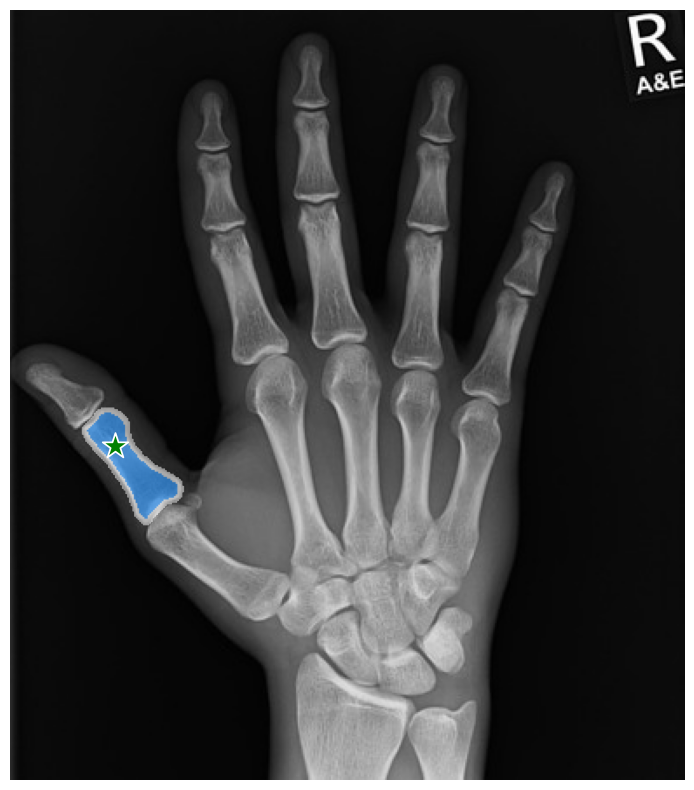

In [27]:
# pick the best mask out of the above 3 masks
mask_input = logits[np.argmax(scores), :,:]

masks, scores, _ = predictor.predict(
    point_coords = input_point,
    point_labels = input_label,
    mask_input = mask_input[None, :,:],
    multimask_output = False
)

masks.shape

show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label)

In [76]:
import json
import numpy as np
import cv2
from pycocotools import mask as maskUtils

def mask_to_coco(mask, image_id, category_id):
    """
    Converts a binary mask to COCO polygon format.
    
    Args:
        mask (np.array): Binary mask (0 and 1).
        image_id (int): Image ID.
        category_id (int): Class ID.
        
    Returns:
        dict: COCO annotation.
    """
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segmentation = []
    for contour in contours:
        if contour.size >= 6:  # A valid polygon requires at least 3 points
            segmentation.append(contour.flatten().tolist())

    rle = maskUtils.encode(np.asfortranarray(mask.astype(np.uint8)))
    area = maskUtils.area(rle).item()
    bbox = maskUtils.toBbox(rle).tolist()  # [x, y, width, height]

    annotation = {
        "image_id": image_id,
        "category_id": category_id,
        "segmentation": segmentation,
        "area": area,
        "bbox": bbox,
        "iscrowd": 0
    }
    return annotation

# Example usage
image_id = 1  # Assign an ID
category_id = 1  # Define category

coco_annotation = mask_to_coco(masks[0], image_id, category_id)

# Save to JSON
coco_output = {
    "images": [{"id": image_id, "file_name": "test_xray.jpg"}],
    "annotations": [coco_annotation],
    "categories": [{"id": 1, "name": "bone"}] 
}

with open("output.json", "w") as f:
    json.dump(coco_output, f, indent=4)
